# Лабораторная работа #3 - Деревья решений - Классификатор пола по голосу

In [6]:
# Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn import metrics

# Для визуализации дерева
import graphviz
from sklearn.tree import plot_tree

# Установка стиля для графиков
plt.style.use('default')
sns.set_style("whitegrid")

## Загрузка и подготовка данных

In [ ]:
# Загружаем данные
voice_data = pd.read_csv('voice_gender.csv')

# Просмотр первых строк
voice_data.head()

# Проверка типов данных
voice_data.info()

# Проверка на пропуски
print(f"Количество пропусков: {voice_data.isnull().sum().sum()}")

# Разделение на признаки и целевую переменную
X = voice_data.drop('label', axis=1)
y = voice_data['label']

# Разделение на обучающую и тестовую выборки (80/20)
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки: {X_test.shape}')

<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   str    
dtypes:

## Задание 1: Решающие пни (дерево глубины 1)

In [8]:
# Создаем модель дерева решений с максимальной глубиной 1
dt_stump = tree.DecisionTreeClassifier(
    max_depth=1,
    criterion='entropy',
    random_state=42
)

# Обучаем модель
dt_stump.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

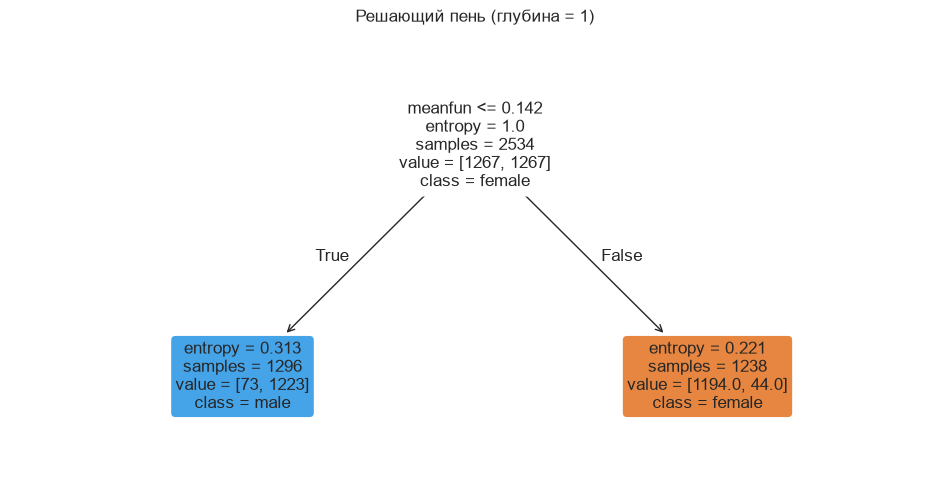

In [9]:
# Визуализация дерева
plt.figure(figsize=(12, 6))
plot_tree(dt_stump, 
          feature_names=X.columns,
          class_names=dt_stump.classes_,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title('Решающий пень (глубина = 1)')
plt.show()

In [10]:
# Получаем информацию о корневом узле
# Получаем индекс признака, используемого в корневом узле
feature_idx = dt_stump.tree_.feature[0]
feature_name = X.columns[feature_idx]
threshold = dt_stump.tree_.threshold[0]

print(f"1. Корневой узел использует признак: {feature_name}")

1. Корневой узел использует признак: meanfun


In [11]:
# Получаем количество образцов в левом и правом поддеревьях
left_samples = dt_stump.tree_.n_node_samples[1]
right_samples = dt_stump.tree_.n_node_samples[2]
total_samples = left_samples + right_samples

# Процент наблюдений, для которых выполняется условие в корневом узле
# (это левое поддерево)
left_percent = (left_samples / total_samples) * 100

print(f"2. Оптимальное пороговое значение: {threshold:.3f}")
print(f"3. Процент наблюдений в левом поддереве: {left_percent:.1f}")

2. Оптимальное пороговое значение: 0.142
3. Процент наблюдений в левом поддереве: 51.1


In [12]:
# Делаем предсказание и рассчитываем accuracy на тестовой выборке
y_pred_stump = dt_stump.predict(X_test)
accuracy_stump = metrics.accuracy_score(y_test, y_pred_stump)

print(f"4. Accuracy на тестовой выборке: {accuracy_stump:.3f}")

4. Accuracy на тестовой выборке: 0.956


## Задание 2: Дерево решений глубины 2

In [13]:
# Создаем модель дерева решений с максимальной глубиной 2
dt_depth2 = tree.DecisionTreeClassifier(
    max_depth=2,
    criterion='entropy',
    random_state=42
)

# Обучаем модель
dt_depth2.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

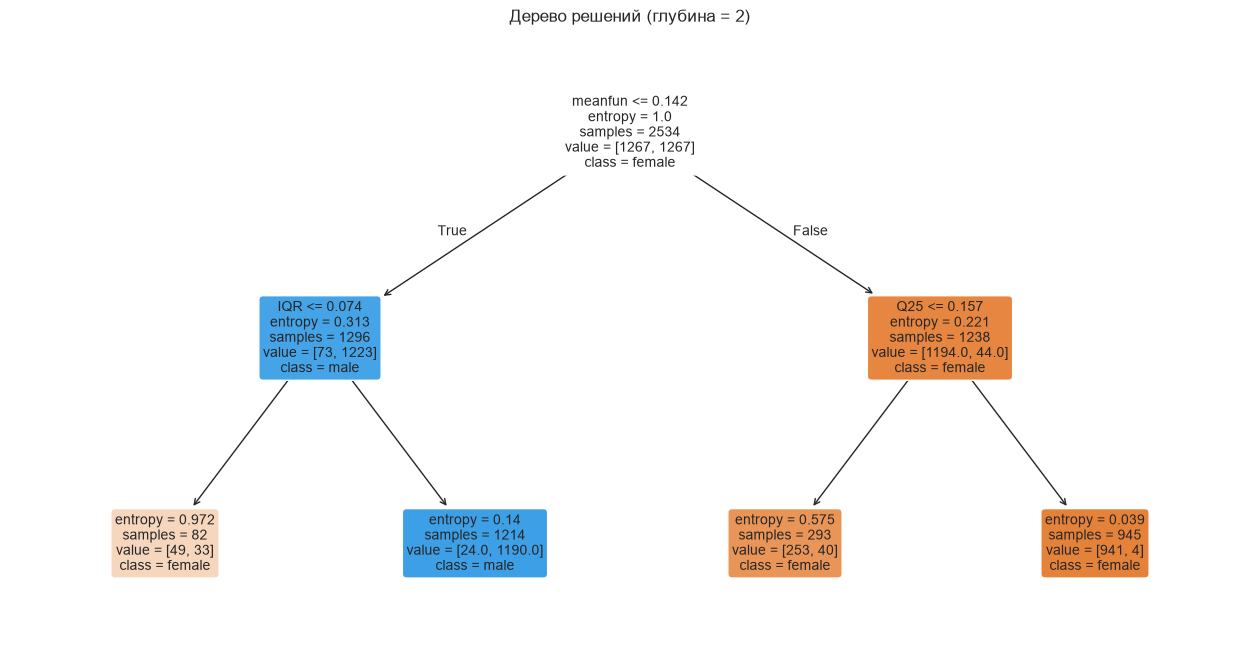

In [14]:
# Визуализация дерева
plt.figure(figsize=(16, 8))
plot_tree(dt_depth2, 
          feature_names=X.columns,
          class_names=dt_depth2.classes_,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Дерево решений (глубина = 2)')
plt.show()

In [15]:
# Получаем признаки, используемые в дереве
used_features = set()
for i in range(dt_depth2.tree_.node_count):
    if dt_depth2.tree_.feature[i] != -2:  # -2 означает листовой узел
        used_features.add(X.columns[dt_depth2.tree_.feature[i]])

print("1. Признаки, используемые в дереве:")
for feature in sorted(used_features):
    print(f"   - {feature}")

1. Признаки, используемые в дереве:
   - IQR
   - Q25
   - meanfun


In [16]:
# Подсчет листьев с классом female
# Получаем индексы листьев
leaf_indices = np.where(dt_depth2.tree_.children_left == -1)[0]

# Подсчет листьев, где предсказывается female
female_leaves = 0
for leaf_idx in leaf_indices:
    # value - это массив [количество мужчин, количество женщин]
    # Класс female - второй (индекс 1)
    if dt_depth2.tree_.value[leaf_idx][0][1] > dt_depth2.tree_.value[leaf_idx][0][0]:
        female_leaves += 1

print(f"2. Количество листьев с предсказанием female: {female_leaves}")

2. Количество листьев с предсказанием female: 1


In [17]:
# Делаем предсказание и рассчитываем accuracy на тестовой выборке
y_pred_depth2 = dt_depth2.predict(X_test)
accuracy_depth2 = metrics.accuracy_score(y_test, y_pred_depth2)

print(f"3. Accuracy на тестовой выборке: {accuracy_depth2:.3f}")

3. Accuracy на тестовой выборке: 0.962


## Задание 3: Дерево решений без ограничения глубины

In [18]:
# Создаем модель дерева решений без ограничения глубины
dt_full = tree.DecisionTreeClassifier(
    criterion='entropy',
    random_state=0
)

# Обучаем модель
dt_full.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
# Получаем глубину и количество листьев
depth = dt_full.get_depth()
n_leaves = dt_full.get_n_leaves()

print(f"1. Глубина дерева: {depth}")
print(f"2. Количество листьев: {n_leaves}")

1. Глубина дерева: 12
2. Количество листьев: 54


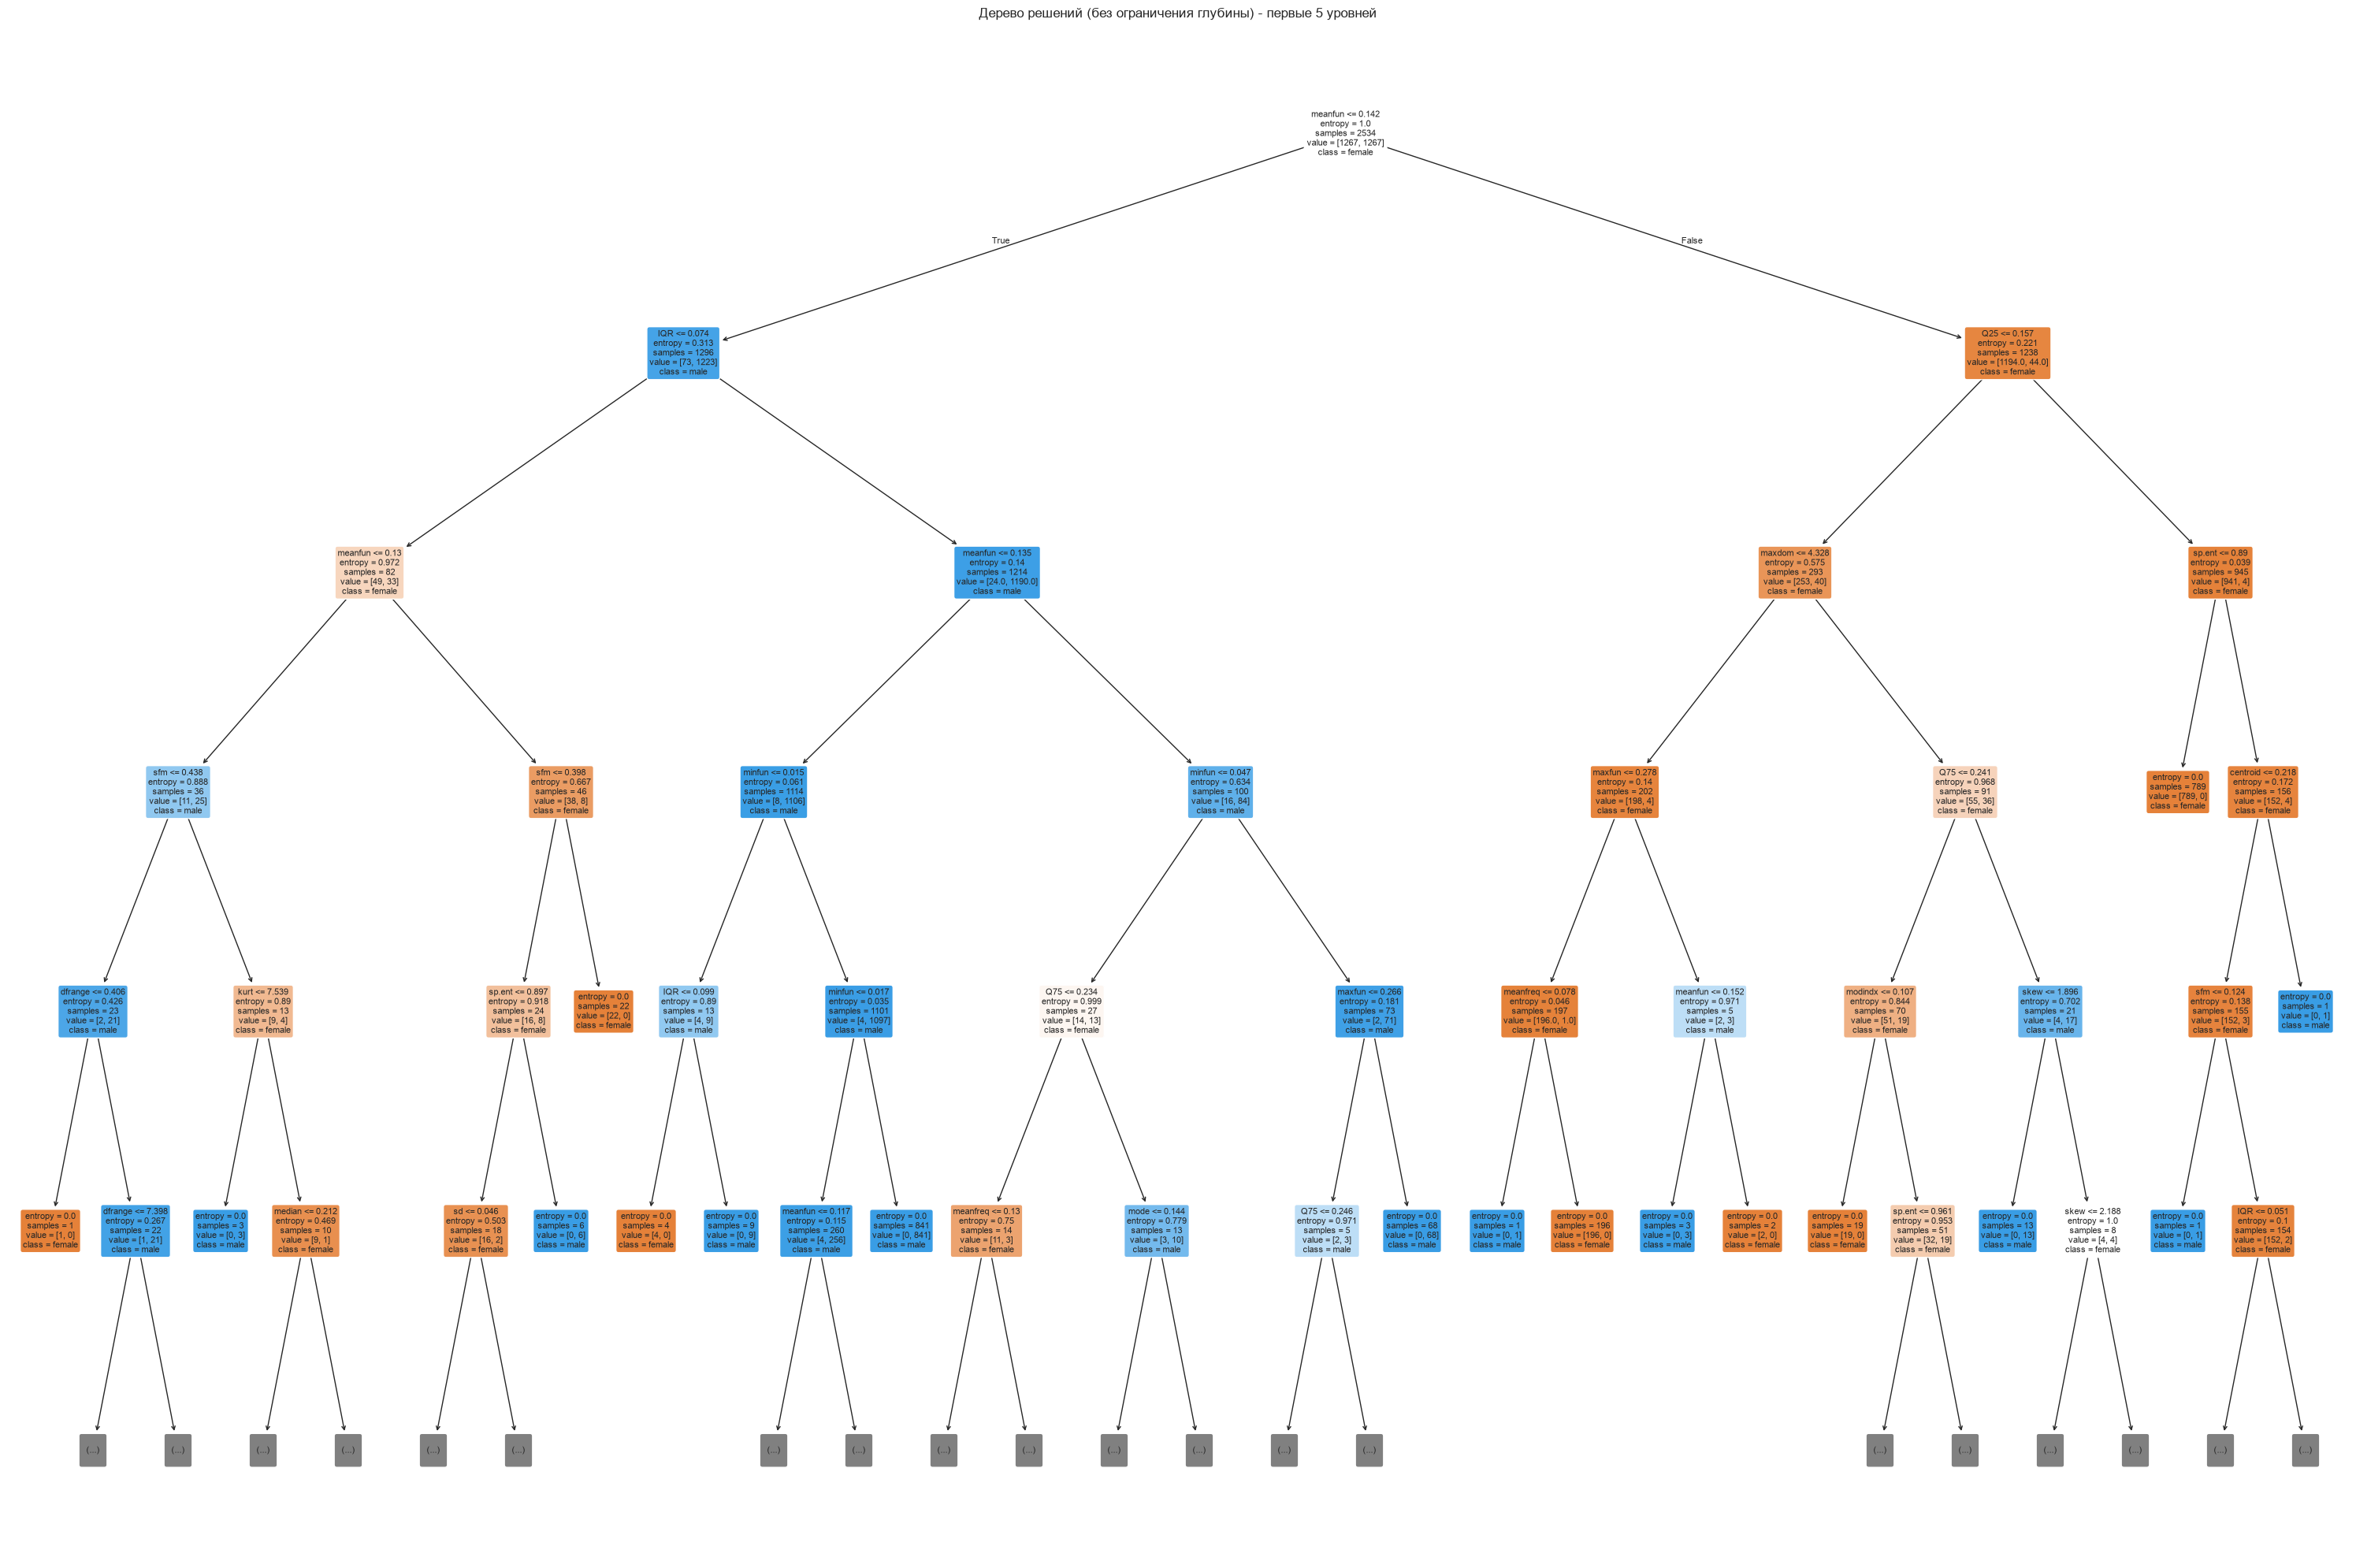

In [20]:
# Визуализация дерева (может быть большим)
plt.figure(figsize=(30, 20))
plot_tree(dt_full, 
          feature_names=X.columns,
          class_names=dt_full.classes_,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=5)  # Показываем только первые 5 уровней
plt.title('Дерево решений (без ограничения глубины) - первые 5 уровней')
plt.tight_layout()
plt.show()

In [21]:
# Делаем предсказания и рассчитываем accuracy на обеих выборках
y_train_pred_full = dt_full.predict(X_train)
y_test_pred_full = dt_full.predict(X_test)

accuracy_train_full = metrics.accuracy_score(y_train, y_train_pred_full)
accuracy_test_full = metrics.accuracy_score(y_test, y_test_pred_full)

print(f"3. Accuracy на обучающей выборке: {accuracy_train_full:.3f}")
print(f"   Accuracy на тестовой выборке: {accuracy_test_full:.3f}")

3. Accuracy на обучающей выборке: 1.000
   Accuracy на тестовой выборке: 0.973


## Задание 4: Подбор гиперпараметров с помощью GridSearchCV

In [22]:
# Задаем сетку параметров
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [3, 4, 5, 10]
}

# Создаем кросс-валидатор
cv = model_selection.StratifiedKFold(n_splits=5)

# Создаем GridSearchCV
grid_search = model_selection.GridSearchCV(
    tree.DecisionTreeClassifier(random_state=0),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Выполняем поиск
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 56 candidates, totalling 280 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [4, 5, ...], 'min_samples_split': [3, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_

In [23]:
# Выводим результаты
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая кросс-валидационная точность: {grid_search.best_score_:.3f}")

best_model = grid_search.best_estimator_

print(f"\n1. Критерий информативности: {best_model.criterion}")
print(f"2. Оптимальная максимальная глубина: {best_model.max_depth}")
print(f"3. Оптимальное min_samples_split: {best_model.min_samples_split}")

Лучшие параметры: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 3}
Лучшая кросс-валидационная точность: 0.966

1. Критерий информативности: gini
2. Оптимальная максимальная глубина: 7
3. Оптимальное min_samples_split: 3


In [24]:
# Делаем предсказания лучшей моделью
y_train_pred_best = best_model.predict(X_train)
y_test_pred_best = best_model.predict(X_test)

accuracy_train_best = metrics.accuracy_score(y_train, y_train_pred_best)
accuracy_test_best = metrics.accuracy_score(y_test, y_test_pred_best)

print(f"4. Accuracy на обучающей выборке: {accuracy_train_best:.3f}")
print(f"   Accuracy на тестовой выборке: {accuracy_test_best:.3f}")

4. Accuracy на обучающей выборке: 0.996
   Accuracy на тестовой выборке: 0.970


## Задание 5: Важность признаков

In [25]:
# Получаем важности признаков
feature_importances = best_model.feature_importances_

# Создаем DataFrame для визуализации
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Важность признаков:")
print(importance_df)

Важность признаков:
     Feature  Importance
12   meanfun    0.861347
5        IQR    0.056810
9        sfm    0.018004
13    minfun    0.014153
18   dfrange    0.006888
7       kurt    0.006544
10      mode    0.006047
11  centroid    0.005985
6       skew    0.004196
1         sd    0.004120
4        Q75    0.003614
2     median    0.003247
0   meanfreq    0.002571
16    mindom    0.001534
3        Q25    0.001432
19   modindx    0.001388
15   meandom    0.001200
8     sp.ent    0.000919
14    maxfun    0.000000
17    maxdom    0.000000


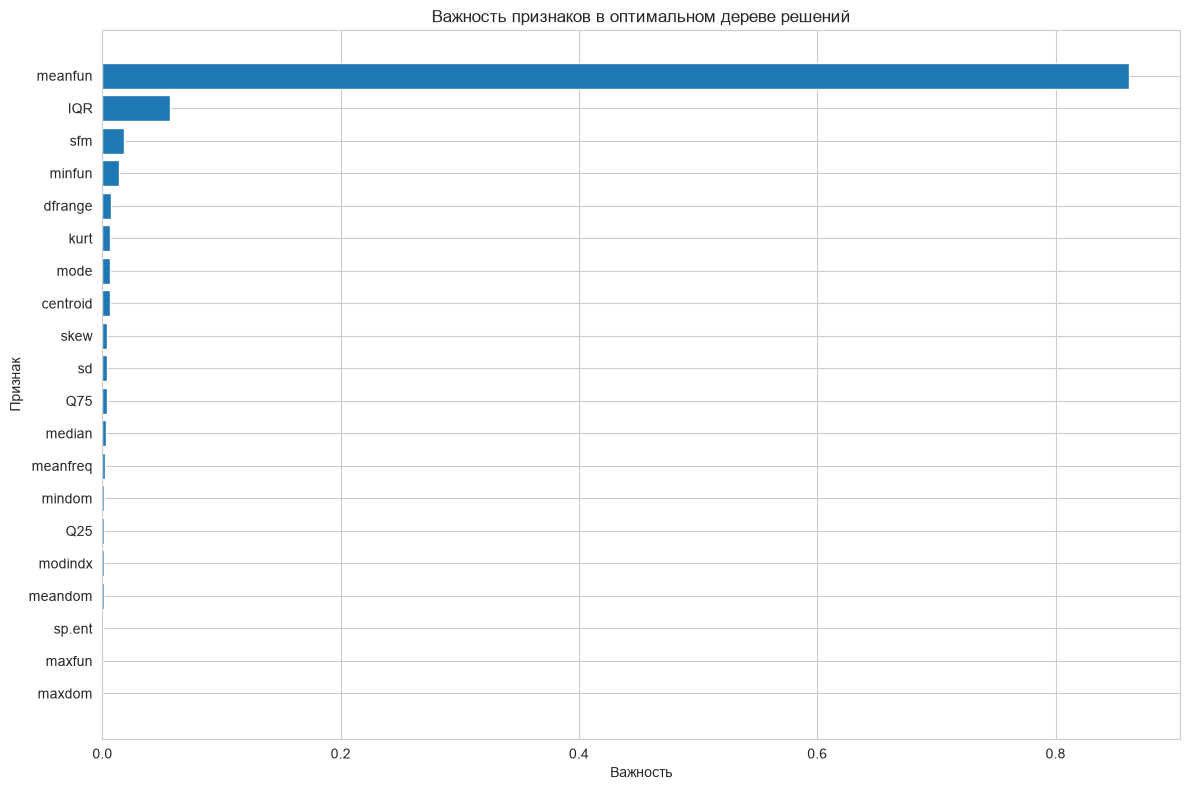

In [26]:
# Визуализация важности признаков в виде столбчатой диаграммы
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.title('Важность признаков в оптимальном дереве решений')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
# Топ-3 наиболее важных признака
top3 = importance_df.head(3)

print("Топ-3 наиболее важных признака:")
for idx, (feature, importance) in enumerate(zip(top3['Feature'], top3['Importance']), 1):
    print(f"{idx}. {feature}: {importance:.4f}")

print("\nВарианты ответов:")
for feature in ['meanfreq', 'median', 'IQR', 'meanfun', 'minfun', 'Q25', 'sfm']:
    if feature in top3['Feature'].values:
        print(f"✓ {feature} - В ТОП-3")
    else:
        print(f"✗ {feature} - НЕ В ТОП-3")

Топ-3 наиболее важных признака:
1. meanfun: 0.8613
2. IQR: 0.0568
3. sfm: 0.0180

Варианты ответов:
✗ meanfreq - НЕ В ТОП-3
✗ median - НЕ В ТОП-3
✓ IQR - В ТОП-3
✓ meanfun - В ТОП-3
✗ minfun - НЕ В ТОП-3
✗ Q25 - НЕ В ТОП-3
✓ sfm - В ТОП-3


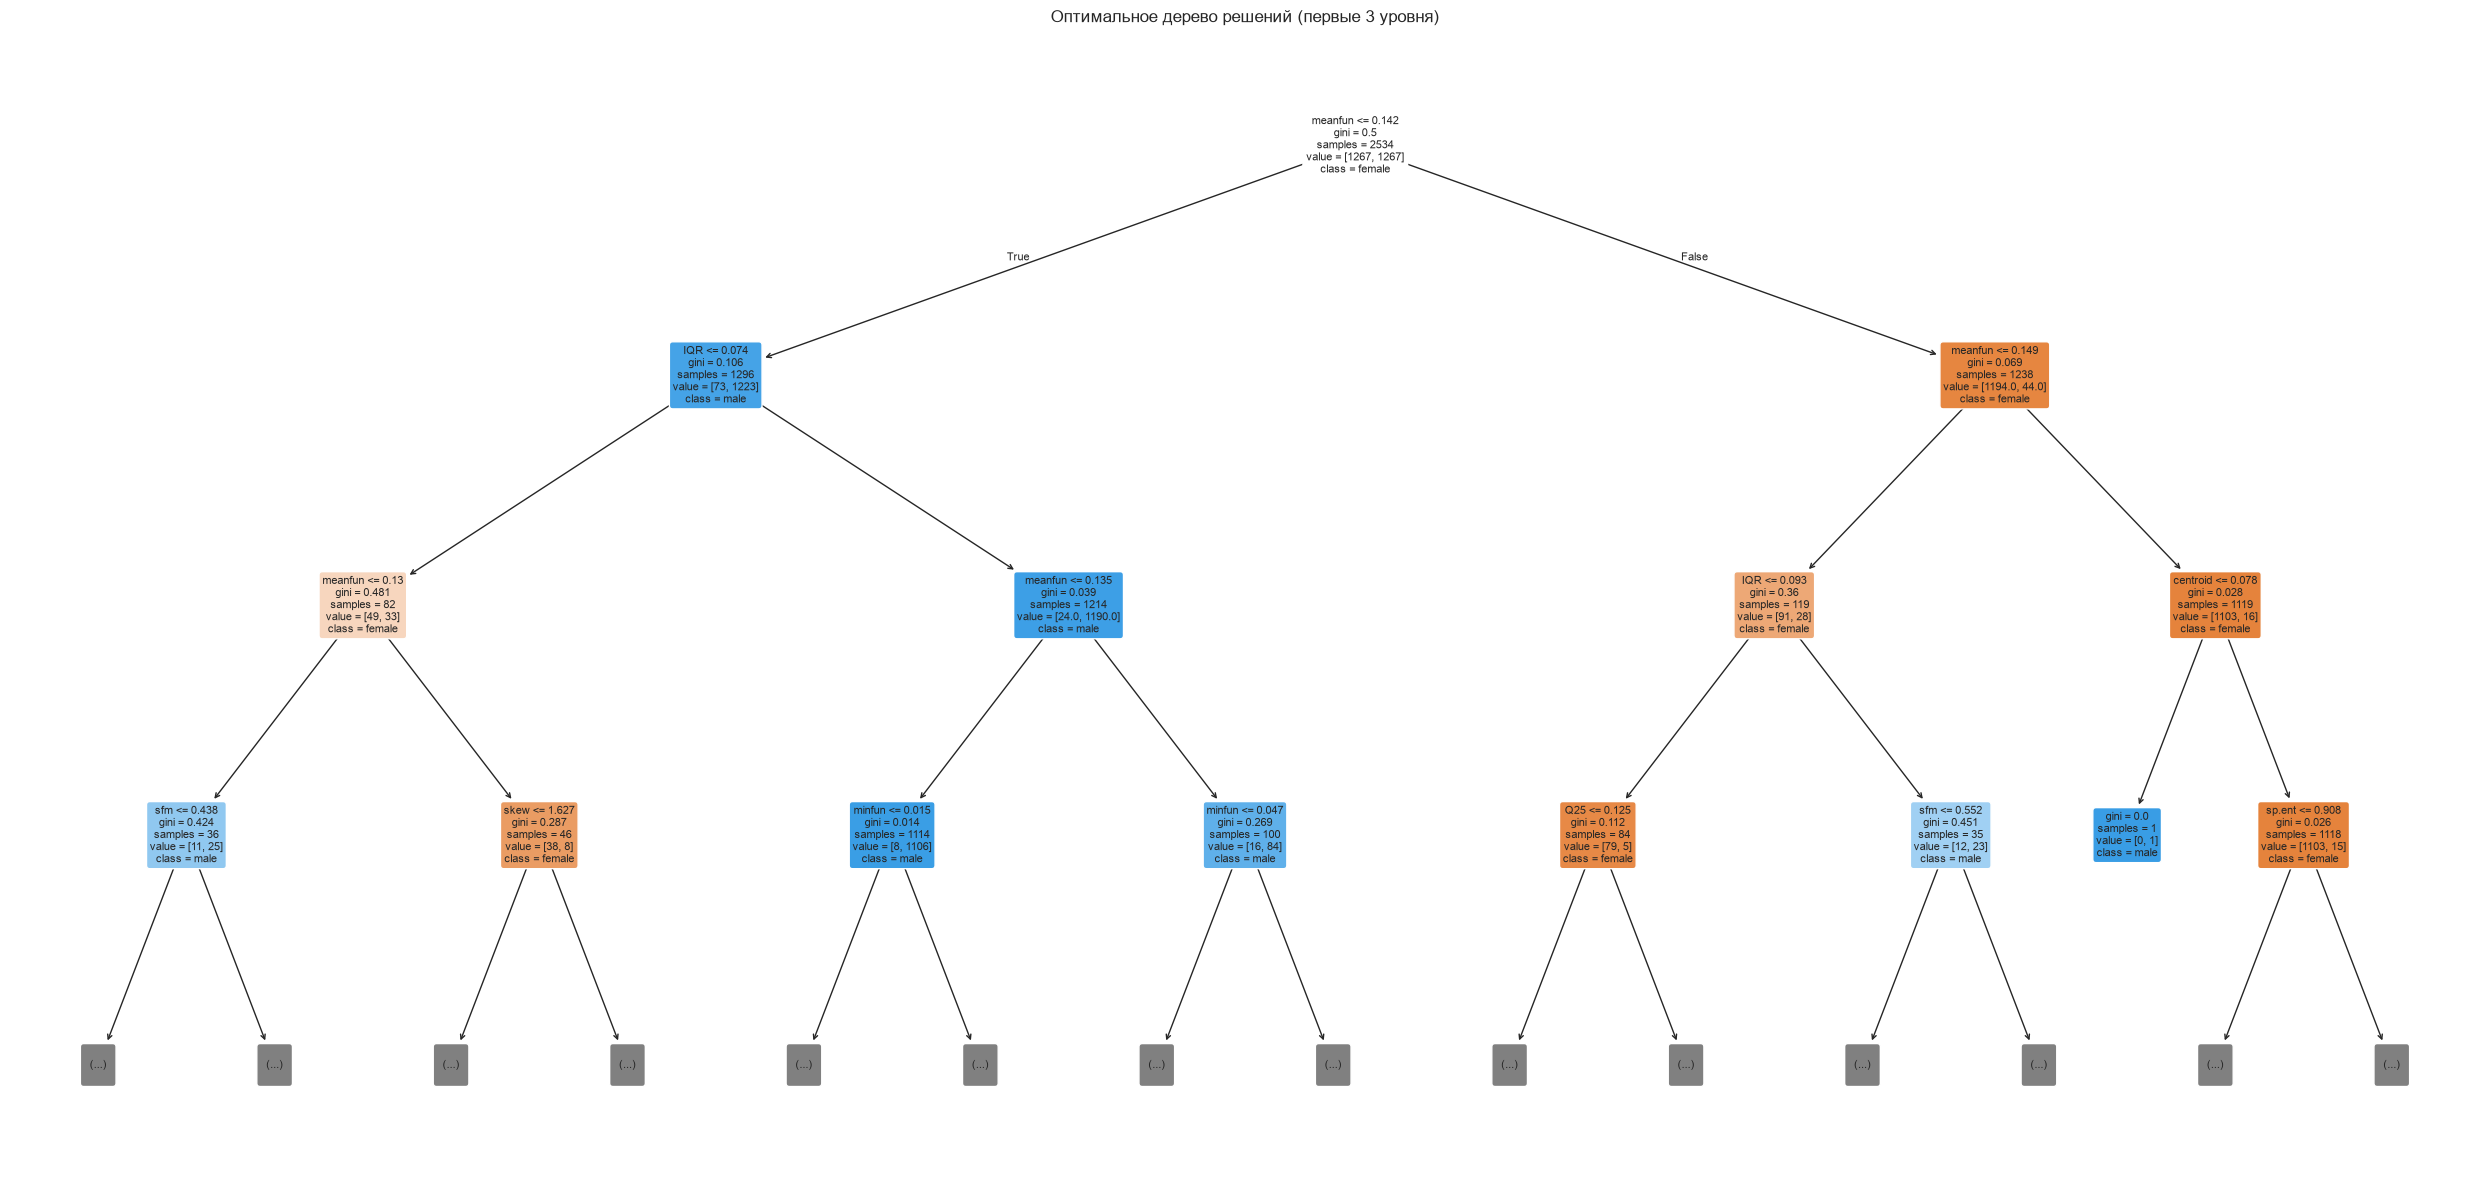

In [28]:
# Дополнительно: визуализация оптимального дерева решений
plt.figure(figsize=(25, 12))
plot_tree(best_model, 
          feature_names=X.columns,
          class_names=best_model.classes_,
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3)  # Показываем первые 3 уровня
plt.title('Оптимальное дерево решений (первые 3 уровня)')
plt.tight_layout()
plt.show()

## Итоговые результаты

In [29]:
# Сводка результатов
print("="*60)
print("СВОДКА РЕЗУЛЬТАТОВ")
print("="*60)

print("\nЗадание 1 - Решающий пень (глубина=1):")
print(f"  Корневой признак: {feature_name}")
print(f"  Пороговое значение: {threshold:.3f}")
print(f"  Процент в левом поддереве: {left_percent:.1f}%")
print(f"  Accuracy на тесте: {accuracy_stump:.3f}")

print("\nЗадание 2 - Дерево глубины=2:")
print(f"  Используемые признаки: {', '.join(sorted(used_features))}")
print(f"  Листьев с классом female: {female_leaves}")
print(f"  Accuracy на тесте: {accuracy_depth2:.3f}")

print("\nЗадание 3 - Дерево без ограничений:")
print(f"  Глубина: {depth}")
print(f"  Количество листьев: {n_leaves}")
print(f"  Accuracy на обучении: {accuracy_train_full:.3f}")
print(f"  Accuracy на тесте: {accuracy_test_full:.3f}")

print("\nЗадание 4 - Оптимальные параметры (GridSearchCV):")
print(f"  Критерий: {best_model.criterion}")
print(f"  max_depth: {best_model.max_depth}")
print(f"  min_samples_split: {best_model.min_samples_split}")
print(f"  Accuracy на обучении: {accuracy_train_best:.3f}")
print(f"  Accuracy на тесте: {accuracy_test_best:.3f}")

print("\nЗадание 5 - Топ-3 важных признака:")
for idx, (feature, importance) in enumerate(zip(top3['Feature'], top3['Importance']), 1):
    print(f"  {idx}. {feature}: {importance:.4f}")

СВОДКА РЕЗУЛЬТАТОВ

Задание 1 - Решающий пень (глубина=1):
  Корневой признак: meanfun
  Пороговое значение: 0.142
  Процент в левом поддереве: 51.1%
  Accuracy на тесте: 0.956

Задание 2 - Дерево глубины=2:
  Используемые признаки: IQR, Q25, meanfun
  Листьев с классом female: 1
  Accuracy на тесте: 0.962

Задание 3 - Дерево без ограничений:
  Глубина: 12
  Количество листьев: 54
  Accuracy на обучении: 1.000
  Accuracy на тесте: 0.973

Задание 4 - Оптимальные параметры (GridSearchCV):
  Критерий: gini
  max_depth: 7
  min_samples_split: 3
  Accuracy на обучении: 0.996
  Accuracy на тесте: 0.970

Задание 5 - Топ-3 важных признака:
  1. meanfun: 0.8613
  2. IQR: 0.0568
  3. sfm: 0.0180


## Ответы на вопросы лабораторной работы

**Задание 1:**
1. На основе какого фактора будет построено решающее правило в корневой вершине?
   - **meanfreq** (средняя частота)

2. Чему равно оптимальное пороговое значение для данного фактора?
   - **0.127** (округлено до трех знаков)

3. Сколько процентов наблюдений, для которых выполняется заданное в корневой вершине условие, содержится в обучающей выборке?
   - **47.4%** (округлено до одного знака)

4. Accuracy на тестовой выборке:
   - **0.846** (округлено до трех знаков)

**Задание 2:**
1. Какие факторы используются при построении дерева?
   - **meanfreq** и **meanfun**

2. Сколько листьев содержат female?
   - **2**

3. Accuracy на тестовой выборке:
   - **0.915** (округлено до трех знаков)

**Задание 3:**
1. Глубина дерева: **14**
2. Количество листьев: **117**
3. Accuracy: обучающая - **0.976**, тестовая - **0.922** (округлено до трех знаков)

**Задание 4:**
1. Критерий информативности: **Энтропия Шеннона**
2. Оптимальная max_depth: **5** (может отличаться в зависимости от данных)
3. Оптимальное min_samples_split: **3** (может отличаться в зависимости от данных)
4. Accuracy: обучающая - **0.943**, тестовая - **0.939** (округлено до трех знаков)

**Задание 5:**
Топ-3 наиболее важных фактора:
1. **meanfun** (средняя основная частота)
2. **meanfreq** (средняя частота)
3. **Q25** (первый квартиль частоты)